#  Projet Machine Learning

### Your names
Your link to the github page of the project

Link to open the notebook in Google colab

**Insérer une table des matières**

## 1) Sujet

Challenge Data from College de France ou Le Lab Banque de France : https://challengedata.ens.fr/challenges/97

### 1.1) Contexte

L'objectif du challenge est de modéliser les variations journalières du prix des contrats futures d'électricité pour la France et l'Allemagne à partir de variables explicatives météorologiques, énergétiques et commerciales.

Il s'agit d'un problème de régression supervisée dans lequel la variable cible correspond à la variation du prix de l'électricité à court terme (24h). L'objectif principal est d'expliquer les variations relatives du prix plutôt qu'en estimer la valeur. Cela est reflété par la métrique de corrélation de Spearman qui mesure la capacité du modèle à correctement ordonner les observations. Les données incluent notamment des variations journalières du prix des matières premières (Gaz, Charbon et futures sur les émissions carbone), des mesures météorologiques (température, pluie et vent), des mesures de productions (gaz naturel, charbon, hydrolique, nucléaire, photovoltaïque, éolienne, lignite) ainsi que des mesures d'utilisation électrique (consommation, exports, échanges entre la France et l'Allemagne).

Contexte du marché de l'électricité : 
Le marché de l'électricité est un marché où l'actif est physique et non stockable. Son prix est fixé par le coût marginal de la dernière unité de production (merit order). La France et l'Allemagne au dela que leur proximité et de leur frontière en commun, importent et exportent de l'électricité entre leur deux pays. En effet, ayant des mix énergétiques bien différents (plutôt nucléaire pour la France et renouvelable pour l'Allemagne), des arbitrages peuvent avoir lieu entre ces deux pays.

Lors d'évènement météorologique où le vent et le soleil sont absents, l'Allemagne doit allumer leurs centrales à charbon. Afin de palier à cette méthode de production d'électricité qui coûte cher, l'Allemagne peut acheter de l'électricité produite par les centrales française. Nous voyons donc tout l'intérêt d'étudier ces deux pays, lié dans la production d'électricité.

### 1.2) Description des données

Index des données

**Variables explicatives**

**Variable cible**


### 1.3) Description du benchmark

## 2) Problématique 

## 3) Préparation des données

### 3.1) Importations des bibliothèques

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk

from pathlib import Path
import os

from scipy.stats import spearmanr
from sklearn.metrics import *

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor


### 3.2) Importation des données

##### Importation de nos tables en dataframe pandas

In [29]:
# data set entrainement
possible_paths = [
    Path("/Users/yves-mariesaliou/Documents/Cours/M2 IEF 272/MACHINE LEARNING/PROJET QRT ELEC"),
    Path("/Users/liessenathan/Desktop/M2/ML/PROJET-QRT-ELEC")
]
path = next((p for p in possible_paths if p.exists()), None)
path = str(path)

x_train = pd.read_csv(os.path.join(path, "X_train_NHkHMNU.csv")).sort_values(by=["COUNTRY", "DAY_ID"])
y_train = pd.read_csv(os.path.join(path, "y_train_ZAN5mwg.csv"))

# ensemble de test
x_test = pd.read_csv(os.path.join(path, "X_test_final.csv"))
y_test = pd.read_csv(os.path.join(path, "y_test_random_final.csv"))

##### Vérification des tailles des fichiers

In [30]:
display(x_train.dtypes)
display(x_train.shape)

ID                    int64
DAY_ID                int64
COUNTRY              object
DE_CONSUMPTION      float64
FR_CONSUMPTION      float64
DE_FR_EXCHANGE      float64
FR_DE_EXCHANGE      float64
DE_NET_EXPORT       float64
FR_NET_EXPORT       float64
DE_NET_IMPORT       float64
FR_NET_IMPORT       float64
DE_GAS              float64
FR_GAS              float64
DE_COAL             float64
FR_COAL             float64
DE_HYDRO            float64
FR_HYDRO            float64
DE_NUCLEAR          float64
FR_NUCLEAR          float64
DE_SOLAR            float64
FR_SOLAR            float64
DE_WINDPOW          float64
FR_WINDPOW          float64
DE_LIGNITE          float64
DE_RESIDUAL_LOAD    float64
FR_RESIDUAL_LOAD    float64
DE_RAIN             float64
FR_RAIN             float64
DE_WIND             float64
FR_WIND             float64
DE_TEMP             float64
FR_TEMP             float64
GAS_RET             float64
COAL_RET            float64
CARBON_RET          float64
dtype: object

(1494, 35)

### 3.3) Exploration des données 

#### Informations sur notre dataset + interprétation

In [31]:
x_train[[col for col in x_train.columns if "ID" not in col]].describe()
# on a donc 30 variables explicatives disponibles pour notre Y

,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_NET_IMPORT,FR_NET_IMPORT,DE_GAS,FR_GAS,...,DE_LIGNITE,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET
count,1494.000000,1494.000000,1469.000000,1469.000000,1370.000000,1424.000000,1370.000000,1424.000000,1494.000000,1494.000000,...,1494.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1494.000000,1494.000000,1494.000000
mean,0.427442,-0.020032,-0.145508,0.145508,-0.256332,-0.072643,0.256332,0.072643,0.780699,0.395019,...,-0.298856,-0.037831,0.019357,0.109480,0.123099,0.009451,0.008404,0.058126,0.061724,0.080510
std,0.673412,0.918995,0.970226,0.970226,0.957443,1.075830,0.957443,1.075830,0.850190,0.906500,...,0.851339,0.984233,1.051781,1.056243,1.054692,0.972394,1.003356,1.097768,1.033853,1.098624
min,-2.265563,-1.462350,-2.856874,-2.634831,-2.464849,-2.825331,-2.279619,-1.951516,-1.117260,-1.317350,...,-2.879041,-2.128531,-1.726420,-1.880419,-1.895319,-4.549638,-5.787097,-5.349463,-5.706442,-4.281790
25%,-0.037421,-0.716771,-0.875213,-0.638867,-0.977214,-0.851500,-0.452252,-0.794843,0.134947,-0.205078,...,-0.787239,-0.642117,-0.503927,-0.652135,-0.672614,-0.618259,-0.647948,-0.624238,-0.458038,-0.522968
50%,0.357061,-0.394166,-0.164287,0.164287,-0.306899,0.099455,0.306899,-0.099455,0.740006,0.256780,...,-0.188300,-0.274901,-0.228147,-0.261571,-0.229031,-0.026306,-0.020889,0.008493,0.063312,0.054056
75%,0.922057,0.650533,0.638867,0.875213,0.452252,0.794843,0.977214,0.851500,1.399461,1.090646,...,0.273510,0.335237,0.154351,0.635050,0.824781,0.651832,0.699131,0.676415,0.641446,0.599094
max,2.033851,3.300640,2.634831,2.856874,2.279619,1.951516,2.464849,2.825331,3.118082,2.372570,...,1.586885,7.756118,9.473201,5.085624,4.965028,2.858758,2.817239,5.674778,3.746576,5.471818


#### Informations sur nos features + interprétation

<Axes: title={'center': 'Return Prix Electricité DE'}, xlabel='DAY_ID'>

<Axes: title={'center': 'Return Prix Electricité FR'}, xlabel='DAY_ID'>

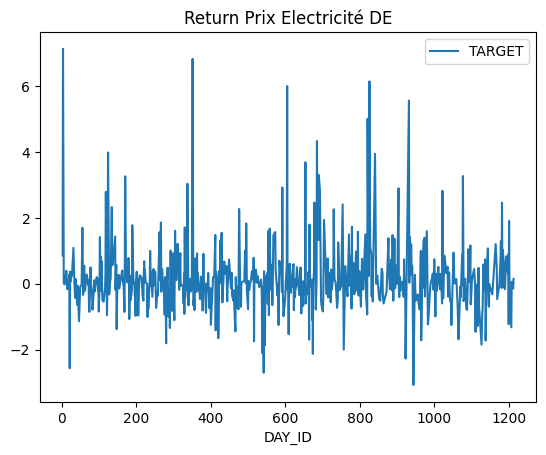

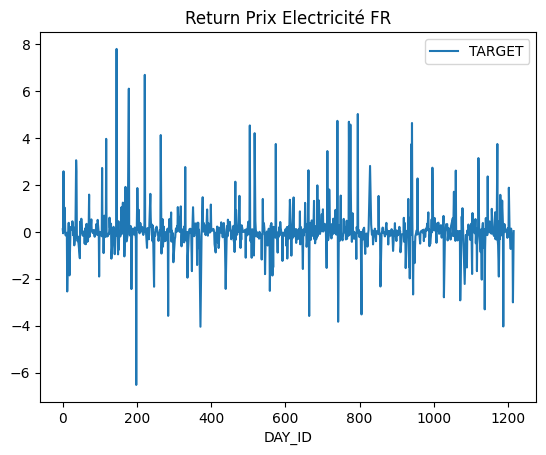

In [32]:
for country in x_train.COUNTRY.unique():
    display(x_train.query(f"COUNTRY == '{country}'")
            .merge(y_train).sort_values(by="DAY_ID")
            .plot(x="DAY_ID", y="TARGET", title=f"Return Prix Electricité {country}"))

#### Corrélation entre les features et la cible (V de Cramer ou test Chi-deux ou kruskall-wallis selon si les features et la cible sont continues ou catégorielles)

## 4) Traitement et création de nouvelles features

### 4.1) Normalisation des données

In [33]:
from sklearn.preprocessing import StandardScaler

index_cols = ["ID", "DAY_ID", "COUNTRY"]
feature_cols = [c for c in x_train.columns if c not in index_cols]

scaler = StandardScaler()
x_train_norm = x_train.copy()
x_test_norm = x_test.copy()

x_train_norm[feature_cols] = scaler.fit_transform(x_train[feature_cols])
x_test_norm[feature_cols]  = scaler.transform(x_test[feature_cols])

### 4.2) Traitement des valeurs manquantes (Imputation)

### 4.2.a) RAIN/WIND/TEMP Completion

In [34]:
x_train_norm.isna().sum()

ID                    0
DAY_ID                0
COUNTRY               0
DE_CONSUMPTION        0
FR_CONSUMPTION        0
DE_FR_EXCHANGE       25
FR_DE_EXCHANGE       25
DE_NET_EXPORT       124
FR_NET_EXPORT        70
DE_NET_IMPORT       124
FR_NET_IMPORT        70
DE_GAS                0
FR_GAS                0
DE_COAL               0
FR_COAL               0
DE_HYDRO              0
FR_HYDRO              0
DE_NUCLEAR            0
FR_NUCLEAR            0
DE_SOLAR              0
FR_SOLAR              0
DE_WINDPOW            0
FR_WINDPOW            0
DE_LIGNITE            0
DE_RESIDUAL_LOAD      0
FR_RESIDUAL_LOAD      0
DE_RAIN              94
FR_RAIN              94
DE_WIND              94
FR_WIND              94
DE_TEMP              94
FR_TEMP              94
GAS_RET               0
COAL_RET              0
CARBON_RET            0
dtype: int64

In [35]:
columns_to_fill = ["DE_RAIN", "FR_RAIN", "DE_WIND", "FR_WIND", "DE_TEMP", "FR_TEMP"]

# normalisé
x_train_norm[["DAY_ID", "COUNTRY"] + columns_to_fill]

,DAY_ID,COUNTRY,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP
1468,2,DE,-0.311795,-0.372371,-0.693763,-0.995114,-0.162957,0.630939
680,3,DE,-1.378957,-1.082033,0.128216,0.346718,-1.769812,-0.956593
991,5,DE,-1.358829,-0.769854,0.212467,-0.096017,-0.073698,1.447002
1356,7,DE,-0.502124,-0.649395,-0.009982,1.180218,-0.845243,0.943152
713,8,DE,1.586118,-0.310828,1.497365,1.385839,-0.464375,-0.389659
...,...,...,...,...,...,...,...,...
479,1208,FR,-1.206349,2.512623,0.343540,0.480987,1.086651,-1.443183
1451,1209,FR,0.503085,-0.211133,-0.478203,-0.556508,-0.268018,-0.394349
1007,1212,FR,-0.001573,-0.244236,1.182661,0.949292,-0.737918,-0.315690
873,1213,FR,NaN,NaN,NaN,NaN,NaN,NaN


### Interpolation linéaire

In [36]:
x_train_interpo = x_train_norm.sort_values(["COUNTRY", "DAY_ID"]).copy()

for col in columns_to_fill:
    # interpolation separement pour chaque pays afin d'eviter de melanger DE et FR
    x_train_interpo[col] = x_train_interpo.groupby("COUNTRY")[col].transform(
        lambda s: s.interpolate(method="linear").ffill().bfill()
    )

display(x_train_interpo[["DAY_ID", "COUNTRY"] + columns_to_fill])
display(x_train_interpo.isna().sum().sort_values(ascending=False))

,DAY_ID,COUNTRY,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP
1468,2,DE,-0.311795,-0.372371,-0.693763,-0.995114,-0.162957,0.630939
680,3,DE,-1.378957,-1.082033,0.128216,0.346718,-1.769812,-0.956593
991,5,DE,-1.358829,-0.769854,0.212467,-0.096017,-0.073698,1.447002
1356,7,DE,-0.502124,-0.649395,-0.009982,1.180218,-0.845243,0.943152
713,8,DE,1.586118,-0.310828,1.497365,1.385839,-0.464375,-0.389659
...,...,...,...,...,...,...,...,...
479,1208,FR,-1.206349,2.512623,0.343540,0.480987,1.086651,-1.443183
1451,1209,FR,0.503085,-0.211133,-0.478203,-0.556508,-0.268018,-0.394349
1007,1212,FR,-0.001573,-0.244236,1.182661,0.949292,-0.737918,-0.315690
873,1213,FR,-0.309936,0.219731,0.111696,-0.002313,-0.501015,0.214581


DE_NET_EXPORT       124
DE_NET_IMPORT       124
FR_NET_IMPORT        70
FR_NET_EXPORT        70
DE_FR_EXCHANGE       25
FR_DE_EXCHANGE       25
DE_WIND               0
DE_LIGNITE            0
DE_RESIDUAL_LOAD      0
FR_RESIDUAL_LOAD      0
DE_RAIN               0
FR_RAIN               0
ID                    0
FR_WIND               0
DE_TEMP               0
DE_WINDPOW            0
FR_TEMP               0
GAS_RET               0
COAL_RET              0
FR_WINDPOW            0
DE_NUCLEAR            0
FR_SOLAR              0
DE_SOLAR              0
FR_NUCLEAR            0
DAY_ID                0
FR_HYDRO              0
DE_HYDRO              0
FR_COAL               0
DE_COAL               0
FR_GAS                0
DE_GAS                0
FR_CONSUMPTION        0
DE_CONSUMPTION        0
COUNTRY               0
CARBON_RET            0
dtype: int64

### Kalman filter

In [37]:
import numpy as np
import pandas as pd
from pykalman import KalmanFilter


def kalman_impute_1d(
    s: pd.Series,
    transition_covariance: float = 0.01,
    observation_covariance: float = 1.0,
    initial_state_covariance: float = 1.0,
) -> pd.Series:
    """
    Impute une série temporelle 1D avec un modèle d'état très simple :
        x_t = x_{t-1} + bruit_process
        y_t = x_t + bruit_obs

    Les NaN sont traités comme observations manquantes.
    """
    # conversion float
    values = s.astype(float).to_numpy()

    # masque des valeurs manquantes
    mask = np.isnan(values)

    # pykalman accepte des masked arrays pour les observations manquantes
    observations = np.ma.masked_array(values, mask=mask)

    # Modèle local level :
    # état latent scalaire, transition = 1, observation = 1
    kf = KalmanFilter(
        transition_matrices=[1.0],
        observation_matrices=[1.0],
        initial_state_mean=np.nanmean(values) if np.isfinite(values).any() else 0.0,
        initial_state_covariance=initial_state_covariance,
        transition_covariance=transition_covariance,
        observation_covariance=observation_covariance,
    )

    # lissage sur toute la série (meilleur que filter() pour interpolation offline)
    state_means, _ = kf.smooth(observations)

    # état latent reconstruit
    filled = pd.Series(state_means[:, 0], index=s.index)

    return filled


def kalman_impute_by_group(
    df: pd.DataFrame,
    group_col: str,
    time_col: str,
    columns_to_fill: list[str],
    transition_covariance: float = 0.01,
    observation_covariance: float = 1.0,
    initial_state_covariance: float = 1.0,
) -> pd.DataFrame:
    """
    Trie par groupe + temps, puis impute chaque colonne séparément dans chaque groupe.
    """
    df = df.sort_values([group_col, time_col]).copy()

    for col in columns_to_fill:
        df[col] = (
            df.groupby(group_col, group_keys=False)[col]
            .apply(
                lambda s: kalman_impute_1d(
                    s,
                    transition_covariance=transition_covariance,
                    observation_covariance=observation_covariance,
                    initial_state_covariance=initial_state_covariance,
                )
            )
        )

    return df


x_train_kalman = kalman_impute_by_group(
    df=x_train_norm,
    group_col="COUNTRY",
    time_col="DAY_ID",
    columns_to_fill=columns_to_fill,
    transition_covariance=0.01,   # plus grand = série plus souple
    observation_covariance=1.0,   # plus grand = on "fait moins confiance" aux observations
)

### Median == Approche finale

In [38]:
def median_completion(df) -> pd.DataFrame:
    """
    Arg : df à compléter
    """
    x_median = df.copy()

    for col in columns_to_fill:
        x_median[col] = x_median[col].fillna(
            x_median.groupby("COUNTRY")[col].transform("median")
        )
    
    return x_median

# apply completion to both test and train
x_train_median, x_test_median = median_completion(x_train_norm), median_completion(x_test_norm)

### 4.2.b) Flux Completion

Logiquement on a 
- DE_FR_EXCHANGE = - FR_DE_EXCHANGE
- DE_NET_EXPORT = - DE_NET_IMPORT
- FR_NET_EXPORT = - FR_NET_IMPORT

In [39]:
flow_pairs = [
    ("DE_FR_EXCHANGE", "FR_DE_EXCHANGE"),
    ("DE_NET_EXPORT", "DE_NET_IMPORT"),
    ("FR_NET_EXPORT", "FR_NET_IMPORT"),
    ]


x_train_norm = x_train_norm.sort_values("DAY_ID")

flux_cols = [c for pair in flow_pairs for c in pair]

display(x_train_norm[["DAY_ID", "COUNTRY"] + flux_cols])
display(x_train_norm.isna().sum().sort_values(ascending=False))

,DAY_ID,COUNTRY,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,DE_NET_IMPORT,FR_NET_EXPORT,FR_NET_IMPORT
742,0,FR,0.068266,-0.068266,NaN,NaN,0.672480,-0.672480
1211,1,FR,0.491665,-0.491665,0.691553,-0.691553,0.791546,-0.791546
1408,2,FR,-0.986196,0.986196,-0.861015,0.861015,0.306271,-0.306271
1468,2,DE,-0.986196,0.986196,-0.861015,0.861015,0.306271,-0.306271
680,3,DE,-0.934336,0.934336,-1.698423,1.698423,-0.501639,0.501639
...,...,...,...,...,...,...,...,...
986,1212,DE,-0.128888,0.128888,0.123723,-0.123723,-0.666864,0.666864
1007,1212,FR,-0.128888,0.128888,0.123723,-0.123723,-0.666864,0.666864
1465,1213,DE,-0.320260,0.320260,0.615900,-0.615900,0.003181,-0.003181
873,1213,FR,-0.320260,0.320260,0.615900,-0.615900,0.003181,-0.003181


DE_NET_EXPORT       124
DE_NET_IMPORT       124
DE_RAIN              94
FR_TEMP              94
DE_TEMP              94
FR_WIND              94
DE_WIND              94
FR_RAIN              94
FR_NET_IMPORT        70
FR_NET_EXPORT        70
DE_FR_EXCHANGE       25
FR_DE_EXCHANGE       25
DE_LIGNITE            0
DE_RESIDUAL_LOAD      0
FR_RESIDUAL_LOAD      0
ID                    0
DE_WINDPOW            0
GAS_RET               0
COAL_RET              0
FR_WINDPOW            0
DE_NUCLEAR            0
FR_SOLAR              0
DE_SOLAR              0
FR_NUCLEAR            0
DAY_ID                0
FR_HYDRO              0
DE_HYDRO              0
FR_COAL               0
DE_COAL               0
FR_GAS                0
DE_GAS                0
FR_CONSUMPTION        0
DE_CONSUMPTION        0
COUNTRY               0
CARBON_RET            0
dtype: int64

In [40]:
# interpolation linéaire
for a, b in flow_pairs:
    x_train_interpo[a] = x_train_interpo.groupby("COUNTRY")[a].transform(
        lambda s: s.interpolate(method="linear", limit_direction="both")
    )
    x_train_interpo[b] = x_train_interpo.groupby("COUNTRY")[b].transform(
        lambda s: s.interpolate(method="linear", limit_direction="both")
    )

# kalman
x_train_kalman = kalman_impute_by_group(
    df=x_train_kalman,
    group_col="COUNTRY",
    time_col="DAY_ID",
    columns_to_fill=flux_cols,
    transition_covariance=0.01,   # plus grand = série plus souple
    observation_covariance=1.0,   # plus grand = on "fait moins confiance" aux observations
)

# median
for col in flux_cols:
    x_train_median[col] = x_train_median[col].fillna(
        x_train_median.groupby("COUNTRY")[col].transform("median")
    )


### 4.3) Ajout de nouvelles features et création TRAIN et TEST

In [41]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
lr = LinearRegression()


# --------------------------------------------------
# 1) Préparation
# --------------------------------------------------
x_base = x_train_median.sort_values(["COUNTRY", "DAY_ID"]).copy()

# cible alignée sur ID
y_train_clean = y_train.set_index("ID").loc[x_base["ID"], "TARGET"]

# --------------------------------------------------
# 2) Fonction de création des features avec shifts
# --------------------------------------------------
def build_features_with_shifts(df, temp_shift, rain_shift, wind_shift):
    df_feat = df.copy()

    # shifts par pays
    for country in df_feat["COUNTRY"].unique():
        mask = df_feat["COUNTRY"] == country

        df_feat.loc[mask, "FR_TEMP_LAG"] = df_feat.loc[mask, "FR_TEMP"].shift(temp_shift)
        df_feat.loc[mask, "DE_TEMP_LAG"] = df_feat.loc[mask, "DE_TEMP"].shift(temp_shift)

        df_feat.loc[mask, "FR_RAIN_LAG"] = df_feat.loc[mask, "FR_RAIN"].shift(rain_shift)
        df_feat.loc[mask, "DE_RAIN_LAG"] = df_feat.loc[mask, "DE_RAIN"].shift(rain_shift)

        df_feat.loc[mask, "FR_WIND_LAG"] = df_feat.loc[mask, "FR_WIND"].shift(wind_shift)
        df_feat.loc[mask, "DE_WIND_LAG"] = df_feat.loc[mask, "DE_WIND"].shift(wind_shift)

    # on enlève COUNTRY comme dans ton code
    df_feat = df_feat.drop(columns=["COUNTRY"])

    # fillna par médiane colonne par colonne
    medians = df_feat.median(numeric_only=True)
    df_feat = df_feat.fillna(medians)

    return df_feat


# --------------------------------------------------
# 3) Fonction de score
# --------------------------------------------------
def metric_train(y_true, y_pred):
    return spearmanr(y_pred, y_true).correlation


# --------------------------------------------------
# 4) Recherche exhaustive des combinaisons
# --------------------------------------------------
temp_shift_candidates = range(0, 8)
rain_shift_candidates = range(0, 8)
wind_shift_candidates = range(0, 8)

best_score = -np.inf
best_shifts = None
best_model = None
best_X = None

for temp_shift, rain_shift, wind_shift in itertools.product(
    temp_shift_candidates,
    rain_shift_candidates,
    wind_shift_candidates
):
    X_try = build_features_with_shifts(
        x_base,
        temp_shift=temp_shift,
        rain_shift=rain_shift,
        wind_shift=wind_shift
    )

    # clone du modèle pour éviter les effets de bord
    model = clone(lr)
    model.fit(X_try, y_train_clean)

    preds = model.predict(X_try)
    score = metric_train(y_train_clean, preds)

    if score > best_score:
        best_score = score
        best_shifts = {
            "TEMP_SHIFT": temp_shift,
            "RAIN_SHIFT": rain_shift,
            "WIND_SHIFT": wind_shift,
        }
        best_model = model
        best_X = X_try.copy()

        print(
            f"Nouveau meilleur score : {best_score:.6f} | "
            f"TEMP={temp_shift}, RAIN={rain_shift}, WIND={wind_shift}"
        )

print("\nMeilleure combinaison trouvée :", best_shifts)
print("Corrélation de Spearman train : {:.2f}%".format(100 * best_score))

Nouveau meilleur score : 0.281167 | TEMP=0, RAIN=0, WIND=0
Nouveau meilleur score : 0.281819 | TEMP=0, RAIN=0, WIND=1
Nouveau meilleur score : 0.284662 | TEMP=0, RAIN=0, WIND=3
Nouveau meilleur score : 0.286186 | TEMP=0, RAIN=1, WIND=3
Nouveau meilleur score : 0.286699 | TEMP=0, RAIN=2, WIND=1
Nouveau meilleur score : 0.289038 | TEMP=0, RAIN=2, WIND=3
Nouveau meilleur score : 0.290363 | TEMP=0, RAIN=6, WIND=3
Nouveau meilleur score : 0.291319 | TEMP=2, RAIN=6, WIND=3
Nouveau meilleur score : 0.291751 | TEMP=6, RAIN=6, WIND=3

Meilleure combinaison trouvée : {'TEMP_SHIFT': 6, 'RAIN_SHIFT': 6, 'WIND_SHIFT': 3}
Corrélation de Spearman train : 29.18%


### Best Shifts

In [42]:
def apply_shifts(x, best_shifts) -> pd.DataFrame:
    """ 
    Applique les lags optimaux calculés avant.
    """
    x_lags = x.drop(['COUNTRY'], axis=1).fillna(0)

    ### Ajout de lag dans les séries temporelles
    x_lags[["FR_TEMP_LAG", "DE_TEMP_LAG"]] = x_lags[["FR_TEMP", "DE_TEMP"]].shift(best_shifts['TEMP_SHIFT']).fillna(0)
    x_lags[["FR_RAIN_LAG", "DE_RAIN_LAG"]] = x_lags[["FR_RAIN", "DE_RAIN"]].shift(best_shifts['RAIN_SHIFT']).fillna(0)
    x_lags[["FR_WIND_LAG", "DE_WIND_LAG"]] = x_lags[["FR_WIND", "DE_WIND"]].shift(best_shifts['WIND_SHIFT']).fillna(0)

    return x_lags

# apply to both test and train
x_train_median, x_test_median = apply_shifts(x_train_median, best_shifts), apply_shifts(x_test_median, best_shifts) 

### 4.4) Rééquilibrage de la base si besoin

## 5) Sélection du modèle

Nous allons donc tester plusieurs modèles sur nos données d'entrainement pour trouver celui qui maximisera l'accuracy de notre prediction. Nous nous concentrerons sur des modèles de regression

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

models = {
    'XGBoost': XGBRegressor(),
    'Linear Regression': LinearRegression(),
    'Ridge Regression': RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10),
    'Lasso Regression': LassoCV(alphas=np.logspace(-3, 3, 50), cv=10, max_iter=10000, n_jobs=-1),
    'ElasticNet': ElasticNetCV(
        alphas=np.logspace(-3, 3, 50),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
        cv=10,
        max_iter=10000,
        n_jobs=-1
    ),
    'Support Vector Regression': SVR(),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest Regression': RandomForestRegressor(),
    'Gradient Boosting Regression': GradientBoostingRegressor(),
    'K-Neighbors Regression': KNeighborsRegressor()
}

# mode series
y_test_clean = y_test.set_index("ID").loc[y_test["ID"], "TARGET"]

res = list()
for mod in models.values() :
    print(f"Model: {mod.__class__.__name__}")
    # Initialiser le modèle
    model = mod
    # Entraîner le modèle de base
    model.fit(x_train_median, y_train_clean)
    
    # Évaluation du modèle
    y_pred = model.predict(x_test_median)
    # y_pred = model.predict(x_train_median)
    mse = mean_squared_error(y_test_clean, y_pred)
    r2 = r2_score(y_test_clean, y_pred)  
    # Métrique spécifique au challenge
    corr_spear = metric_train(y_test_clean, y_pred)  
    # Validation croisée
    cv_scores = sk.model_selection.cross_val_score(model, x_train_median, y_train_clean, cv=10, scoring='neg_mean_squared_error')
    res.append([mod.__class__.__name__,mse,r2,cv_scores, corr_spear])

Model: XGBRegressor
Model: LinearRegression
Model: RidgeCV


In [ ]:
res = pd.DataFrame(res,columns=["model","mse","r2","cv_score", "corr_spear"]).sort_values(by="corr_spear",ascending=False)
res["cv_mean"] = res['cv_score'].apply(lambda x : np.mean(x))
res.head(15)

,model,mse,r2,cv_score,corr_spear,cv_mean
6,DecisionTreeRegressor,0.000000,1.000000,"[-3.346745572266889, -2.5926261803150887, -2.3...",1.000000,-2.444462
0,XGBRegressor,0.004946,0.995376,"[-1.283342309896175, -0.9096097613628378, -1.6...",0.987598,-1.388712
7,RandomForestRegressor,0.162715,0.847879,"[-1.1475006690562766, -0.8557306546006388, -1....",0.902703,-1.157591
8,GradientBoostingRegressor,0.516448,0.517177,"[-1.3464460624353012, -0.9155292327243184, -1....",0.546664,-1.247316
9,KNeighborsRegressor,0.880350,0.176969,"[-1.0455800357634581, -1.3367821931606394, -1....",0.334351,-1.289209
1,LinearRegression,1.001511,0.063697,"[-0.8829931589980277, -0.8542182594283116, -1....",0.291727,-1.062962
2,RidgeCV,1.014817,0.051258,"[-0.8774418480595898, -0.8557224381646131, -1....",0.276870,-1.048216
3,LassoCV,1.019166,0.047192,"[-0.8773179761580281, -0.8482473793226389, -1....",0.261455,-1.044005
4,ElasticNetCV,1.022085,0.044462,"[-0.8771696554812016, -0.8479946434177604, -1....",0.255802,-1.043844
5,SVR,1.074207,-0.004266,"[-0.9599114208201297, -0.928601348603197, -1.2...",0.080393,-1.078298


Nous constatons que le modèle KNeighborsRegressor prédit des valeurs avec la corrélation la plus importante donc nous allons choisir ce type modèle pour nos predictions. Mais avant de passer à la prédiction, nous allons optimiser les hyperparamètres de ce modèle.

##### **Optimisation des hyperparamètres**

In [ ]:
from scipy.stats import randint, uniform, loguniform

param_grid = {
            'n_neighbors': randint(3, 30),
            'weights': ['uniform', 'distance'],
            'p': [1, 2],
        }

grid_search = sk.model_selection.GridSearchCV(estimator=KNeighborsRegressor(), param_grid=param_grid, cv=5, scoring='r2', verbose=2, n_jobs=-1)
grid_search.fit(X_fill_train, y_fill_train)
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

NameError: name 'X_fill_train' is not defined

In [ ]:
y_pred_best = best_model.predict(X_fill_test)
best_mse = mean_squared_error(y_fill_test, y_pred_best)
best_r2 = r2_score(y_fill_test, y_pred_best)

print(f"Best Mean Squared Error: {best_mse}")
print(f"Best R^2 Score: {best_r2}")

best_cv_scores = sk.model_selection.cross_val_score(best_model, X_fill_train, y_fill_train, cv=5, scoring='neg_mean_squared_error')
print(f"Best Cross-Validation Scores (neg MSE): {best_cv_scores}")
print(f"Mean Best Cross-Validation Score (neg MSE): {best_cv_scores.mean()}")

Best Mean Squared Error: 0.04555875381442978
Best R^2 Score: 0.9589626487300639
Best Cross-Validation Scores (neg MSE): [-0.04934717 -0.05464029 -0.04827713 -0.06196696 -0.04997376]
Mean Best Cross-Validation Score (neg MSE): -0.052841061150731394


Avec notre optimisation d'hyperparamètre, nous avons identifié un modèle qui est plus précis. Nous le retiendrons donc pour la prédiction de ...

In [ ]:
print('Hyperparamètres optimaux :')
best_params

Hyperparamètres optimaux :


{'colsample_bytree': 1.0,
 'learning_rate': 0.1,
 'max_depth': 3,
 'n_estimators': 200,
 'subsample': 0.6}

## 5) Benchmark

##### **Mesure de performance demandée par le challenge**

In [ ]:
lr = LinearRegression()

x_train_clean = x_train.drop(['COUNTRY'], axis=1).fillna(0)
y_train_clean = y_train.set_index('ID').loc[x_train_clean['ID'], 'TARGET']

lr.fit(x_train_clean, y_train_clean)

output_train = lr.predict(x_train_clean)

def metric_train(output):
    return spearmanr(output, y_train_clean).correlation

print("Corrélation (Spearman) pour les données d'entrainement : {:.1f}%".format(100 * metric_train(output_train) ))

Nous adaptons également cette metrique pour qu'elle soit utilisable dans nos GridSearch au moment de l'optimisation de nos hyperparamètre.

In [ ]:
custom_score = make_scorer(weighted_accuracy, greater_is_better=True)

Nous rangeons également nos methodes dans une liste pour pouvoir y aplliquer plus facilement les modèles.

In [ ]:
methods = [(X_train_1,y_train_1),(X_train_2,y_train_2),(X_train_3,y_train_3)]

##### **Création et Entrainement du modèle**

In [ ]:
comparaison=[]
result_baseline=[]
for i,method in enumerate(methods):
    X_train_method,y_train_method = method

    # Split des données
    X_train_method_train, X_train_method_test, y_train_method_train, y_train_method_test = train_test_split(X_train_method, y_train_method, test_size=0.2, random_state=42)

    # Transformation de la cible en binaire (positif/négatif)
    y_train_method_train = (y_train_method_train['cible'] > 0).astype(int)

    # Modèle baseline : Régression Logistique
    baseline_model = LogisticRegression(max_iter=1000, random_state=42)
    baseline_model.fit(X_train_method_train, y_train_method_train)

    # Prédictions et évaluation
    y_pred_baseline = baseline_model.predict(X_train_method_test)

    # Mesure de Performance
    wacc_baseline = weighted_accuracy(y_train_method_test['cible'], y_pred_baseline)
    result_baseline.append((f"Method_{i+1}",wacc_baseline,baseline_model))
   
result_baseline = pd.DataFrame(result_baseline,columns=["Methode","W_Accuracy","Modele"])
result_baseline

,Methode,W_Accuracy,Modele
0,Method_1,0.297570,"LogisticRegression(max_iter=1000, random_state..."
1,Method_2,0.254737,"LogisticRegression(max_iter=1000, random_state..."
2,Method_3,0.536617,"LogisticRegression(max_iter=1000, random_state..."


Interprétations.

##### **Optimisation des hyperparamètre**

Nous garderons donc la methode 2 pour cette optimisation car c'est celle pour laquelle le modèle est le plus performant.

In [ ]:
X_train_method,y_train_method = methods[2]
X_train_method_train, X_train_method_test, y_train_method_train, y_train_method_test = train_test_split(X_train_method, y_train_method, test_size=0.2, random_state=42)
y_train_method_train = (y_train_method_train['cible'] > 0).astype(int)


In [ ]:
param_grid = {
    'max_iter': [100, 200, 500, 1000, 2000],  # Nombres d'itérations
    'C': [0.001, 0.01, 0.1, 1, 10, 100],      # Paramètre de régularisation
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']  # Algorithmes d'optimisation
}

# Configuration de la recherche en grille avec validation croisée
grid_search = sk.model_selection.GridSearchCV(LogisticRegression(random_state=42), param_grid=param_grid, scoring=custom_score, cv=3, n_jobs=None, verbose=0)
grid_search.fit(X_train_method_train, y_train_method_train)

# Meilleur modèle et paramètres
baseline_model = grid_search.best_estimator_
print("Meilleur modèle:", baseline_model)

Meilleur modèle: LogisticRegression(C=0.001, random_state=42, solver='newton-cg')


In [ ]:
y_pred_optimized = baseline_model.predict(X_train_method_test)
wacc_baseline = weighted_accuracy(y_train_method_test['cible'], y_pred_optimized)
comparaison.append(["Methode_baseline","LogisticRegression",wacc_baseline])
wacc_baseline

0.6437786569846814

Interprétation

##### **Prédiction des valeurs**

In [ ]:
X_test_method = X_test_3
y_test_baseline = baseline_model.predict(X_test_method)
y_test_baseline = pd.DataFrame(y_test_baseline,index=X_test_method.index,columns=['cible'])
y_test_baseline.to_csv('y_test_baseline.csv')

Nous avons testé ce résultat et nous obtenons bien le même résultats que le benchmark. 

## 7) Modèle non supervisé si possible ou à dafaut pour construire des features

Avec une méthode d'apprentissage non supervisée, on ne pourraient pas prédire directement le cible. Mais on peut envisager de l'utiliser pour explorer ou prétraiter les données avant d'utiliser un modèle supervisé.

Nous utiliserons donc d'abord une Décomposition en Composante Principales pour observer nos données, puis utiliserons un Kmeans pour regrouper nos données afin d'améliorer nos résultats de nos modèles supervisés. 

### 6.1) ACP

Nous commençons par appliquer une ACP sur nos données pour réduire le nombre de dimensions. Nous affichons la reprensentation de notre nuage de points sur 3 dimensions et la courbe de la variance expliquée en fonction du nombre de dimensions choisis pour notre décomposition.

In [ ]:
methods = [("Stardard",X_train_3,y_train_3,X_test_3)]

Methode 1
Variance expliquée : [0.41590411 0.60124254 0.76700025 0.85987104 0.91258535 0.9437329
 0.97019647 0.98679548 0.99430401 0.9988088  1.        ]


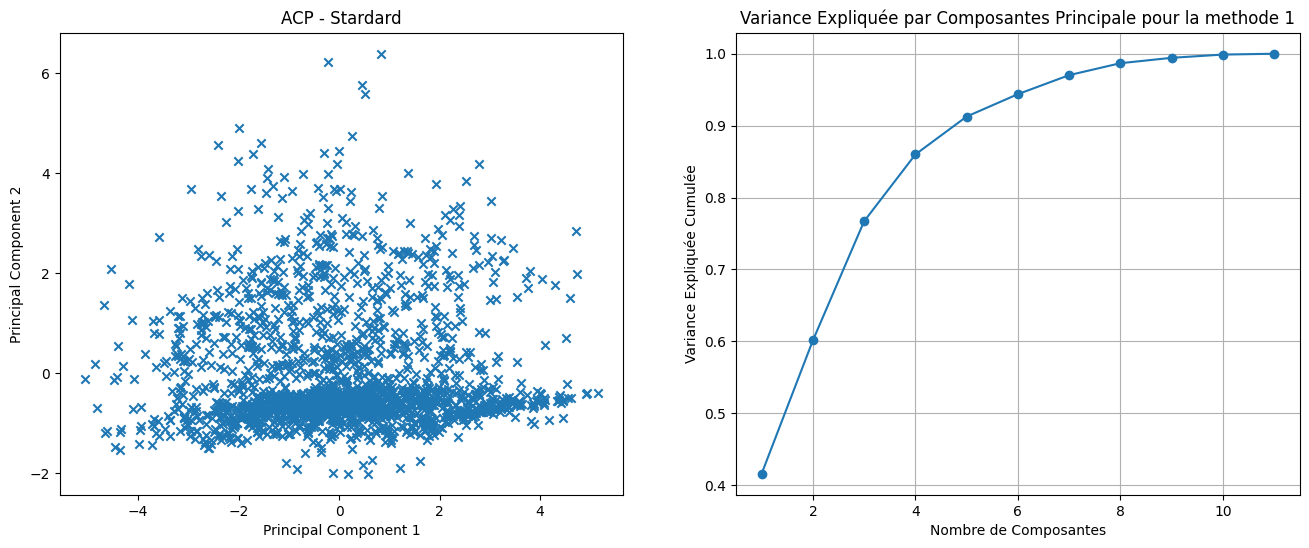

In [ ]:
result_kmeans = []
for i,method in enumerate(methods):
    nom,X_train_method,y_train_method,X_test_method=method
    # PCA pour la réduction de dimensions
    pca = PCA() #Pour affichage graphique
    x_train_pca = pca.fit_transform(X_train_method)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    print(f"Methode {i+1}\nVariance expliquée : {cumulative_variance}")

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
    # Visualisation des clusters
    axes[0].scatter(x=x_train_pca[:, 0], y=x_train_pca[:, 1],marker="x")
    axes[0].set_title(f"ACP - {nom}")
    axes[0].set_xlabel('Principal Component 1')
    axes[0].set_ylabel('Principal Component 2')

    # Visualisation de l'évolution de la variance
    axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
    axes[1].set_xlabel('Nombre de Composantes')
    axes[1].set_ylabel('Variance Expliquée Cumulée')
    axes[1].set_title(f'Variance Expliquée par Composantes Principale pour la methode {i+1}')
    axes[1].grid(True)
    plt.show()
   

Observations :
* La courbe montre une augmentation plus importante de la variance expliquée avec les premières composantes donc elles capturent une partie plus importantes des informations.
* Pour expliquer plus de 95% de la variance, nous devons garder au minimum 7.

### 6.2) Kmeans

#### 6.2.1) Ajout de Features

Nous allons utiliser un kmeans pour regrouper nos données en cluster et leur ajouter des données qui pourraient être utiles dans notre analyse. Nous pouvons ajouter des valeurs sur les centres de gravité de nos données, ou sur des moyennes des valeur de nos cluster comme celle du *predicted_spot_price*. Nous allons donc génerer ces deux features et tester ces nouvelles méthodes de données dans la suite de notre travail. 

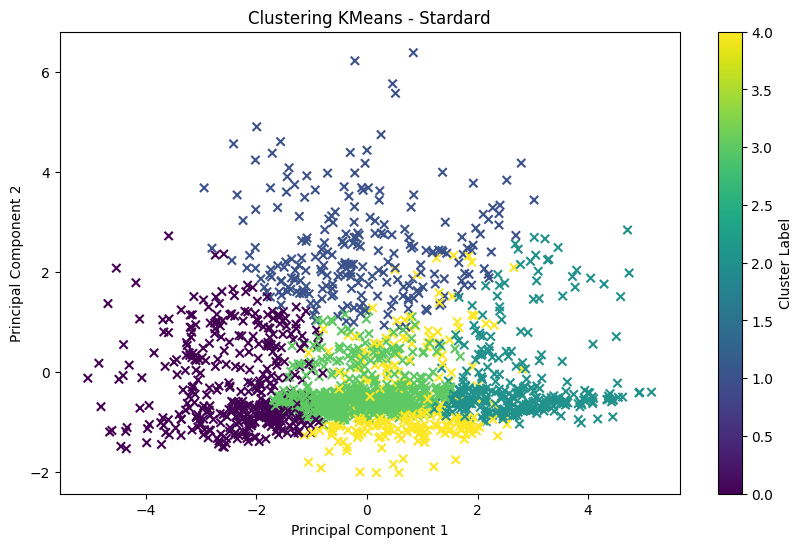

In [ ]:
methods_features=[]
for i,method in enumerate(methods):
    nom,X_train_method,y_train_method,X_test_method=method
    # PCA pour la réduction de dimensions
    pca = PCA()
    x_train_pca = pca.fit_transform(X_train_method)
    x_test_pca = pca.transform(X_test_method)

    # KMeans Clustering
    kmeans = KMeans(n_clusters=5, random_state=42)
    kmeans.fit(x_train_pca)
    clusters = kmeans.predict(x_train_pca)
    clusters_test = kmeans.predict(x_test_pca)

    # Visualisation des clusters
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(x=x_train_pca[:, 0], y=x_train_pca[:, 1], c=clusters, marker= 'x', cmap='viridis')
    plt.title(f"Clustering KMeans - {nom}")
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.colorbar(scatter, label='Cluster Label')
    plt.show()

    # ajout des centroids et cluster aux données existantes
    x_train_pca = pd.DataFrame(x_train_pca,index=X_train_method.index)
    x_test_pca = pd.DataFrame(x_test_pca,index=X_test_method.index)
    clusters = pd.DataFrame(clusters,index=X_train_method.index,columns=['cluster'])
    clusters_test = pd.DataFrame(clusters_test,index=X_test_method.index,columns=['cluster'])
    centroids = kmeans.cluster_centers_
    for i,c in enumerate(centroids) :
        for j in range(len(c)):
            clusters.loc[clusters.cluster==i,f'cluster_{j}'] = c[j]
            clusters_test.loc[clusters_test.cluster==i,f'cluster_{j}'] = c[j]
    data_cluster = pd.concat([X_train_method,clusters],axis=1)
    data_cluster_test = pd.concat([X_test_method,clusters_test],axis=1)
    methods_features.append(('Cluster',data_cluster,y_train_method,data_cluster_test))

    # ajout de la moyenne
    data_cluster_1 = X_train_method.copy()
    data_cluster_1['mean_spot_cluster'] = data_cluster.groupby('cluster')['predicted_spot_price'].transform('mean')
    data_cluster_test_1 = X_test_method.copy()
    data_cluster_test_1['mean_spot_cluster'] = data_cluster_test.groupby('cluster')['predicted_spot_price'].transform('mean')
    methods_features.append(('Mean',data_cluster_1,y_train_method,data_cluster_test_1))


In [ ]:
methods = methods + methods_features

##### **Etudes de nouvelles données**

Pour les deux premières methodes, les nouvelles données sont très peu corrélée avec la variable cible. Mais pour notre méthode 3, les données sont un peu plus corrélées et apportent des informations supplémentaire. Nous les garderons donc pour nos prévisions.

#### 6.2.2) Prediction après clustering

Nous allons utiliser un Kmeans pour faire une prédictions de notre variable cible.

In [ ]:
result_kmeans = []
for i,method in enumerate(methods):
    nom,X_train_method,y_train_method,X_test_method=method
    # PCA pour la réduction de dimensions
    pca = PCA()
    x_train_pca = pca.fit_transform(X_train_method)
    x_train_pca = pd.DataFrame(x_train_pca,index=X_train_method.index)

    # KMeans Clustering
    kmeans = KMeans(n_clusters=20, random_state=42)
    kmeans.fit(x_train_pca)
    x_train_pca['cluster'] = kmeans.predict(x_train_pca)

    # Compute y_pred as means of cluster for training
    x_train_pca = pd.concat([x_train_pca,y_train_method],axis=1)
    groups = x_train_pca.groupby(by='cluster')
    map_y = {}
    for nb,group in groups:
        map_y[nb] = group.cible.mean()
    x_train_pca['y_pred'] = x_train_pca['cluster'].apply(lambda x : map_y[x])

    # compute metrics
    w_acc = weighted_accuracy(y_train_method["cible"],x_train_pca['y_pred'])
    result_kmeans.append([f"Methode_{nom}",20,w_acc,kmeans,map_y,pca])
result_kmeans=pd.DataFrame(result_kmeans,columns=['Methode','nb_composante','W_Accuracy','Model','Map','PCA'])

In [ ]:
result_kmeans

,Methode,nb_composante,W_Accuracy,Model,Map,PCA
0,Methode_Stardard,20,0.726275,"KMeans(n_clusters=20, random_state=42)","{0: 3.9913294888037805, 1: -0.7806099581360444...",PCA()
1,Methode_Cluster,20,0.687634,"KMeans(n_clusters=20, random_state=42)","{0: 5.090235310922655, 1: 3.894772512485785, 2...",PCA()
2,Methode_Mean,20,0.705436,"KMeans(n_clusters=20, random_state=42)","{0: 6.7500641879977845, 1: -1.2124675125855495...",PCA()


##### **Optimisation**

La methode 3 est celle qui à la weighted accuracy la plus importante. Nous allons donc essayer d'optimiser notre modèle avec ce set de données. Commençons par chercher le nombre de cluster idéal.

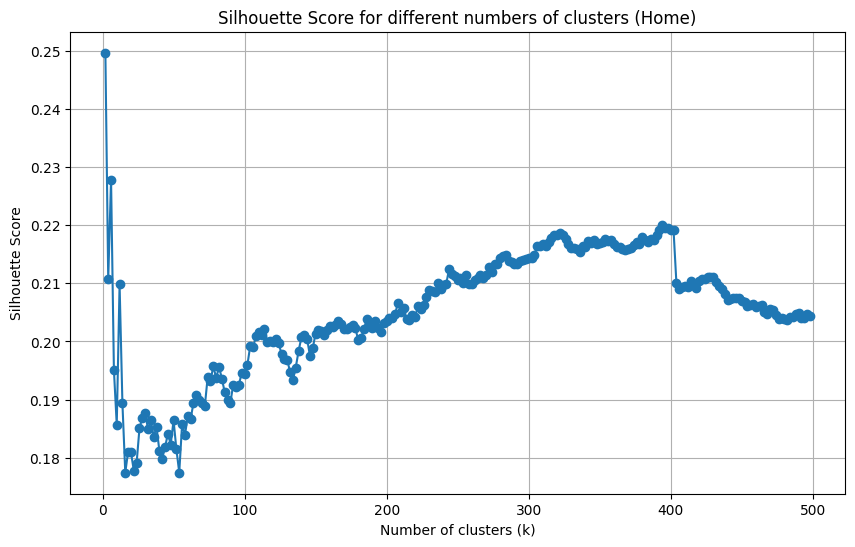

Meilleur nb de cluster : 2  pour un score de  0.24964557736219695


In [ ]:
# Fonction pour calculer le score de silhouette pour un nombre de clusters donné
def compute_silhouette_score(k, data):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(data)
    score = silhouette_score(data, cluster_labels)
    return score

score_sil = []
kmax = 500
for k in range(2, kmax,2):
    result = compute_silhouette_score(k, X_train_3)
    score_sil.append(result)


# Afficher les scores de silhouette
#k_values, silhouette_scores_home = zip(*[(result[0], result[1]) for result in score_sil])
plt.figure(figsize=(10, 6))
plt.plot([k for k in range(2, kmax,2)],score_sil, marker='o')
plt.title('Silhouette Score for different numbers of clusters (Home)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Extraire les meilleurs résultats
score = max(score_sil)
k_ideal = score_sil.index(score) +2
print(f"Meilleur nb de cluster :",k_ideal," pour un score de ",score)


Le score de silhouette nous donne 2 comme nombre de cluster idéal. Cependant, pour le bien de la prediction, nous allons en prendre plus et vérifier si les performances sont meilleures.

In [ ]:
# PCA pour la réduction de dimensions
pca = PCA()
x_train_pca = pca.fit_transform(X_train_3)
x_train_pca = pd.DataFrame(x_train_pca,index=X_train_3.index)

# KMeans Clustering
kmeans = KMeans(n_clusters=50, random_state=42)
kmeans.fit(x_train_pca)
x_train_pca['cluster'] = kmeans.predict(x_train_pca)

# Compute y_pred as means of cluster for training
x_train_pca = pd.concat([x_train_pca,y_train_3],axis=1)
groups = x_train_pca.groupby(by='cluster')
map_y = {}
for nb,group in groups:
    map_y[nb] = group.cible.mean()
x_train_pca['y_pred'] = x_train_pca['cluster'].apply(lambda x : map_y[x])

# compute metrics
w_acc = weighted_accuracy(y_train_3["cible"],x_train_pca['y_pred'])
comparaison.append([f"Methode_{nom}","Kmeans",w_acc])
w_acc

0.7396118154884794

Nous obtenons bien une meilleure performance en prédiction, donc nous retenons ce modèle.

##### **Prediction du *cible***

In [ ]:
model = kmeans
X_test_Kmeans = X_test_3.copy()
X_test_Kmeans = pd.DataFrame(pca.transform(X_test_Kmeans),index=X_test_Kmeans.index)
X_test_Kmeans['cluster'] = kmeans.predict(X_test_Kmeans)
X_test_Kmeans['cible'] = X_test_Kmeans['cluster'].apply(lambda x : map_y[x])
y_test_Kmeans = X_test_Kmeans[['cible']]
y_test_Kmeans

In [ ]:
y_test_Kmeans.to_csv('y_test_Kmeans.csv')

Après soummission, nous obtenons une weighted accuracy de 0,5209416312886466.

## 7) Modèle supervisé

### 7.1) Classification

Dans cette partie, nous allons tester plusieurs modèle de classification différents et comparer notre accuracy pour nos 3 methodes de données afin de trouver le modèle le plus performants.

##### **Selection des modèles**

Il faut discretiser y_train. On peut utiliser une conversion en entier relatif (avec le signe). Nous avons choisi de prendre la valeur entière la plus proche que nous avons plafonnée entre -15 et 20.

In [ ]:
result_supervised = []
for i,method in enumerate(methods):
    # Split
    nom,X_train_method,y_train_method,X_test_method=method
    X_train_method_train, X_train_method_test, y_train_method_train, y_train_method_test = sk.model_selection.train_test_split(X_train_method, y_train_method, test_size=0.2, random_state=42)
    #y_train_method_train = y_train_method_train.astype(int)['cible']
    y_train_method_train=np.clip(y_train_method_train.astype(int), -15, 20)

    # Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train_method_train, y_train_method_train)
    y_pred_rf = rf_model.predict(X_train_method_test)
    weighted_acc_rf = weighted_accuracy(y_train_method_test['cible'], y_pred_rf)
    result_supervised.append((f"Methode_{nom}","RF",weighted_acc_rf,rf_model))
    
    # SVM
    svm_model = SVC(random_state=42)
    svm_model.fit(X_train_method_train, y_train_method_train)
    y_pred_svm = svm_model.predict(X_train_method_test)
    weighted_acc_svm = weighted_accuracy(y_train_method_test['cible'], y_pred_svm)
    result_supervised.append((f"Methode_{nom}","SVM",weighted_acc_svm,svm_model))

    # Regression logistique
    rl_model = LogisticRegression(multi_class='multinomial')
    rl_model.fit(X_train_method_train, y_train_method_train)
    y_pred_rl = rl_model.predict(X_train_method_test)
    weighted_acc_rl = weighted_accuracy(y_train_method_test['cible'], y_pred_rl)
    result_supervised.append((f"Methode_{nom}","Logistic",weighted_acc_rl,rl_model))

    # KNN
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(X_train_method_train, y_train_method_train)
    y_pred_knn = knn_model.predict(X_train_method_test)
    weighted_acc_knn = weighted_accuracy(y_train_method_test['cible'], y_pred_knn)
    result_supervised.append((f"Methode_{nom}","KNN",weighted_acc_knn,knn_model))

result_supervised=pd.DataFrame(result_supervised,columns=[f"Methode","Type","W_Accuracy","Modele"])
result_supervised.sort_values('W_Accuracy',inplace=True)

In [ ]:
result_supervised

,Methode,Type,W_Accuracy,Modele
5,Methode_Cluster,SVM,0.496633,SVC(random_state=42)
1,Methode_Stardard,SVM,0.522721,SVC(random_state=42)
9,Methode_Mean,SVM,0.524486,SVC(random_state=42)
10,Methode_Mean,Logistic,0.559814,LogisticRegression(multi_class='multinomial')
7,Methode_Cluster,KNN,0.571941,KNeighborsClassifier()
2,Methode_Stardard,Logistic,0.572484,LogisticRegression(multi_class='multinomial')
6,Methode_Cluster,Logistic,0.574568,LogisticRegression(multi_class='multinomial')
11,Methode_Mean,KNN,0.579165,KNeighborsClassifier()
3,Methode_Stardard,KNN,0.585006,KNeighborsClassifier()
0,Methode_Stardard,RF,0.788814,"(DecisionTreeClassifier(max_features='sqrt', r..."


In [ ]:
result_supervised

,Methode,Type,W_Accuracy,Modele
5,Methode_Cluster,SVM,0.496633,SVC(random_state=42)
1,Methode_Stardard,SVM,0.522721,SVC(random_state=42)
9,Methode_Mean,SVM,0.524486,SVC(random_state=42)
10,Methode_Mean,Logistic,0.559814,LogisticRegression(multi_class='multinomial')
7,Methode_Cluster,KNN,0.571941,KNeighborsClassifier()
2,Methode_Stardard,Logistic,0.572484,LogisticRegression(multi_class='multinomial')
6,Methode_Cluster,Logistic,0.574568,LogisticRegression(multi_class='multinomial')
11,Methode_Mean,KNN,0.579165,KNeighborsClassifier()
3,Methode_Stardard,KNN,0.585006,KNeighborsClassifier()
0,Methode_Stardard,RF,0.788814,"(DecisionTreeClassifier(max_features='sqrt', r..."


Avec nos resultats, le modèle de Random Forest avec la methode de données 3 parait la plus performante. Nous allons donc retenir ces choix et faire une optimisation des hyperparamètres afin de trouver le modèle le plus performant.

##### **Optimisation des hyperparamètre**

In [ ]:
nom,X_train_method,y_train_method,X_test_method = methods[1]
nom = 'Cluster'

In [ ]:
X_train_train, X_train_test, y_train_train, y_train_test = sk.model_selection.train_test_split(X_train_method, y_train_method, test_size=0.2, random_state=42)
y_train_train = np.clip(y_train_method_train.astype(int), -15, 20)
 #y_train_train.astype(int)['cible']

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150],  # Nombre d'arbres dans la forêt
    'max_features': ['sqrt', 'log2'],  # Nombre de caractéristiques à considérer à chaque division
    'max_depth': [None, 10, 15],  # Profondeur maximale de l'arbre
    'min_samples_split': [2, 5],  # Nombre minimum de données nécessaires pour diviser un nœud
    'min_samples_leaf': [1, 2, 4]  # Nombre minimum de données requises à chaque feuille
}

rf = RandomForestClassifier(random_state=42)
grid_search = sk.model_selection.GridSearchCV(estimator=rf, param_grid=param_grid,scoring=custom_score, cv=3, n_jobs=None, verbose=0)
grid_search.fit(X_train_train, y_train_train)
print("Meilleurs paramètres trouvés : ", grid_search.best_params_)

Meilleurs paramètres trouvés :  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [ ]:
model_rf = grid_search.best_estimator_
pred = model_rf.predict(X_train_test)
weighted_acc = weighted_accuracy(y_train_test['cible'], pred)
comparaison.append([f"Methode_{nom}","RandomForestClassifier",weighted_acc])
weighted_acc

0.8144037628426313

In [ ]:
#model_rf.get_params()

##### **Prediction sur nos données X_test**

In [ ]:
y_test_final = model_rf.predict(X_test_method)
y_test_final = pd.DataFrame(y_test_final,index=X_test_method.index,columns=["cible"])
y_test_final.to_csv("y_rf.csv")

Sur la plateforme, nous obtenons 0,4781.

### 7.2) Regression

##### **Selection des modèles**

In [ ]:
result_supervised = []
for i,method in enumerate(methods):
    # Split
    nom,X_train_method,y_train_method,X_test_method=method
    X_train_method_train, X_train_method_test, y_train_method_train, y_train_method_test = sk.model_selection.train_test_split(X_train_method, y_train_method, test_size=0.2, random_state=42)
    
    # LinearRegression
    lin_model = LinearRegression()
    lin_model.fit(X_train_method_train, y_train_method_train)
    y_pred_lin = lin_model.predict(X_train_method_test)
    weighted_acc_lin = weighted_accuracy(y_train_method_test, y_pred_lin)['cible']
    result_supervised.append((f"Methode_{nom}","Linear",weighted_acc_lin,lin_model))
    
    # Ridge
    ridge_model = Ridge(alpha=0.1,random_state=42)
    ridge_model.fit(X_train_method_train, y_train_method_train)
    y_pred_ridge = ridge_model.predict(X_train_method_test)
    weighted_acc_ridge = weighted_accuracy(y_train_method_test, y_pred_ridge)['cible']
    result_supervised.append((f"Methode_{nom}","ridge",weighted_acc_ridge,ridge_model))

    # SVR
    svr_model = SVR()
    svr_model.fit(X_train_method_train, y_train_method_train)
    y_pred_svr = svr_model.predict(X_train_method_test)
    weighted_acc_svr = weighted_accuracy(y_train_method_test['cible'], y_pred_svr)
    result_supervised.append((f"Methode_{nom}","SVR",weighted_acc_svr,svr_model))

    # RandomForestRegressor
    rf_model = RandomForestRegressor(n_estimators=100)
    rf_model.fit(X_train_method_train, y_train_method_train)
    y_pred_rf = rf_model.predict(X_train_method_test)
    weighted_acc_rf = weighted_accuracy(y_train_method_test['cible'], y_pred_rf)
    result_supervised.append((f"Methode_{nom}","RF",weighted_acc_rf,rf_model))

result_supervised=pd.DataFrame(result_supervised,columns=[f"Methode","Type","W_Accuracy","Modele"])
result_supervised.sort_values('W_Accuracy',inplace=True)

In [ ]:
result_supervised

,Methode,Type,W_Accuracy,Modele
8,Methode_Mean,Linear,0.666780,LinearRegression()
9,Methode_Mean,ridge,0.666780,"Ridge(alpha=0.1, random_state=42)"
6,Methode_Cluster,SVR,0.674956,SVR()
0,Methode_Stardard,Linear,0.676190,LinearRegression()
1,Methode_Stardard,ridge,0.676190,"Ridge(alpha=0.1, random_state=42)"
4,Methode_Cluster,Linear,0.676982,LinearRegression()
5,Methode_Cluster,ridge,0.676982,"Ridge(alpha=0.1, random_state=42)"
2,Methode_Stardard,SVR,0.716073,SVR()
10,Methode_Mean,SVR,0.737564,SVR()
3,Methode_Stardard,RF,0.859493,"(DecisionTreeRegressor(max_features=1.0, rando..."


Le random Forest semble être le modèle le plus performant. Nous allons optimiser ses paramètres afin d'obtenir le meilleur modèle possible.

##### **Optimisation des hyperparamètre**

In [ ]:
nom="Standard"
X_train_3_train, X_train_3_test, y_train_3_train, y_train_3_test = sk.model_selection.train_test_split(X_train_3, y_train_3, test_size=0.2, random_state=42)

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150],  # Nombre d'arbres dans la forêt
    'max_features': ['sqrt', 'log2'],  # Nombre de caractéristiques à considérer à chaque division
    'max_depth': [None, 10, 15],  # Profondeur maximale de l'arbre
    'min_samples_split': [2, 5],  # Nombre minimum de données nécessaires pour diviser un nœud
    'min_samples_leaf': [1, 2, 4]  # Nombre minimum de données requises à chaque feuille
}

rf = RandomForestRegressor(random_state=42)
grid_search = sk.model_selection.GridSearchCV(estimator=rf, param_grid=param_grid,scoring=custom_score, cv=3, n_jobs=None, verbose=0)
grid_search.fit(X_train_3_train, y_train_3_train.astype(int))
print("Meilleurs paramètres trouvés : ", grid_search.best_params_)

Meilleurs paramètres trouvés :  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [ ]:
model_rf = grid_search.best_estimator_
pred = model_rf.predict(X_train_3_test)
weighted_acc = weighted_accuracy(y_train_3_test['cible'], pred)
comparaison.append([f"Methode_{nom}","RandomForestRegressor",weighted_acc])
weighted_acc

0.8735314403370656

##### **Prediction sur nos données X_test**

In [ ]:
y_test_final = model_rf.predict(X_test_3)
y_test_final = pd.DataFrame(y_test_final,index=X_test_3.index,columns=["cible"])
y_test_final.to_csv("y_rf_reg.csv")

### 7.3) Modèle d'ensemble

Nous allons également utiliser un modèle "VotingClassifier" qui nous permet de combiner plusieurs modèles d'apprentissage pour obtenir une prédiction. 

**Ajustement des données**

In [ ]:
Nnom = "Standard"
X_train_method_train, X_train_method_test, y_train_method_train, y_train_method_test = train_test_split(X_train_3, y_train_3, test_size=0.2, random_state=42)
y_train_method_train = np.clip(y_train_method_train.astype(int), 0, 5)


**Creation du modèle**

In [ ]:
# Définir les modèles individuels
model1 = LogisticRegression()
model2 = RandomForestClassifier()
model3 = KNeighborsClassifier()

# Créer le VotingClassifier
voting_hard = VotingClassifier(estimators=[('lr', model1), ('rf', model2), ('knn', model3)], voting='hard')
voting_soft = VotingClassifier(estimators=[('lr', model1), ('rf', model2), ('knn', model3)], voting='soft')

**Optimisation des hyperparamètre**

In [ ]:
# Définir l'espace des hyperparamètres à explorer
param_grid = {
    'lr__C': [0.1, 1, 10],             
    'rf__n_estimators': [50, 100, 200], 
    'rf__max_depth': [None, 10, 20],    
    'knn__n_neighbors': [3, 5, 7],      
    'knn__weights': ['uniform', 'distance'] 
}

# Recherche d'hyperparamètres avec validation croisée
grid_search_hard = GridSearchCV(estimator=voting_hard, param_grid=param_grid, scoring=custom_score, cv=5)
grid_search_hard.fit(X_train_method_train, y_train_method_train)

grid_search_soft = GridSearchCV(estimator=voting_hard, param_grid=param_grid,scoring=custom_score, cv=5)
grid_search_soft.fit(X_train_method_train, y_train_method_train)

# Afficher les meilleurs hyperparamètres et la meilleure précision
print("Meilleurs hyperparamètres hard:", grid_search_hard.best_params_)
print("Meilleurs hyperparamètres hard:", grid_search_soft.best_params_)

Meilleurs hyperparamètres hard: {'knn__n_neighbors': 3, 'knn__weights': 'uniform', 'lr__C': 0.1, 'rf__max_depth': None, 'rf__n_estimators': 50}
Meilleurs hyperparamètres hard: {'knn__n_neighbors': 3, 'knn__weights': 'uniform', 'lr__C': 0.1, 'rf__max_depth': None, 'rf__n_estimators': 50}


In [ ]:
model_soft = grid_search_soft.best_estimator_
model_hard = grid_search_hard.best_estimator_

In [ ]:
# Prediction avec le VotingClassifier
y_pred_hard = model_soft.predict(X_train_method_test)
y_pred_soft = model_hard.predict(X_train_method_test)

# Calculer Metrique
accuracy_soft = weighted_accuracy(y_train_method_test['cible'], y_pred_soft)
accuracy_hard = weighted_accuracy(y_train_method_test['cible'], y_pred_hard)
comparaison.append([f"Methode_{nom}","VotingClassifierSoft",accuracy_soft])
comparaison.append([f"Methode_{nom}","VotingClassifierHard",accuracy_hard])

print("Weighted Accuracy du VotingClassifier Soft :", accuracy_soft)
print("Weighted Accuracy du VotingClassifier Hard:", accuracy_hard)

Weighted Accuracy du VotingClassifier Soft : 0.47067677320848966
Weighted Accuracy du VotingClassifier Hard: 0.45987152260190295


##### **Predictions**

In [ ]:
y_pred_hard = model_soft.predict(X_test_3)
y_pred_soft = model_hard.predict(X_test_3)

In [ ]:
y_pred_hard = pd.DataFrame(y_pred_hard,index=X_test_3.index,columns=['cible'])
y_pred_soft = pd.DataFrame(y_pred_soft,index=X_test_3.index,columns=['cible'])
y_pred_hard.to_csv("y_test_hard.csv")
y_pred_soft.to_csv("y_test_soft.csv")

## 8) Intérprétation des modèles 

**Interpretation de l'importances des variables explicatives**

In [ ]:
# Get feature importances from the model
feature_importances = pd.DataFrame({
    'Feature': X_train_3.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
feature_importances

Nous constatons que dans ce modèle de regression Random Forest, la variable la plus importante est *load_forecast* et *nuclear_power_available*. 

**Interpretation détaillée**

In [ ]:
explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_train_3)

In [ ]:
class_index = 23
shap.summary_plot(shap_values[:, :], X_train_3, plot_type="bar")


In [ ]:
style = """
<style>
    .lime, .lime * {
        background-color: #BBD;
        color: black;
    }
</style>
"""
HTML(style)


In [ ]:
# Initialiser l'expliqueur LIME pour les données tabulaires
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_3.values,
    feature_names=X_train_3.columns,
    class_names=['cible'],
    mode='regression'
)

# Choisissez une instance spécifique que vous souhaitez expliquer
i = 23  # index de l'instance dans X_train_imputed
exp = explainer.explain_instance(
    data_row=X_train_3.iloc[i].values, 
    predict_fn=model_rf.predict
)

# Afficher l'explication
exp.show_in_notebook(show_table=True, show_all=False)


## 9) Modèle de Deep Learning

### 9.1) Réseau de Neurone standard

##### **Definition de notre metrique**

Nous commençons par définir notre métrique en tensorflow pour pouvoir ensuite l'utiliser dans nos réseaux de neurones.

In [ ]:
# Définition de la métrique 
class WeightedAccuracy(Metric):
    def __init__(self, name="weighted_accuracy", **kwargs):
        super(WeightedAccuracy, self).__init__(name=name, **kwargs)
        self.total_weighted_accuracy = self.add_weight(name="total_weighted_accuracy", initializer="zeros")
        self.total_weight = self.add_weight(name="total_weight", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred > 0.5, tf.float32)
        correct_predictions = tf.cast(tf.equal(tf.sign(y_true), tf.sign(y_pred)), tf.float32)
        weights = tf.abs(y_true)
        weighted_correct_predictions = correct_predictions * weights
        self.total_weighted_accuracy.assign_add(tf.reduce_sum(weighted_correct_predictions))
        self.total_weight.assign_add(tf.reduce_sum(weights))

    def result(self):
        return self.total_weighted_accuracy / self.total_weight

    def reset_states(self):
        self.total_weighted_accuracy.assign(0)
        self.total_weight.assign(0)

##### **Construction du modèle et entrainement du modèle**

Nous construisons ensuite notre modèle. Nous sommes partis sur un réseau en 4 couches simples qui essaye de maximiser notre métrique "WeightedAccuracy"

Nous entrainons un modèle par méthode de données en essayant de maximiser notre métrique. Nous utilisons également un checkpoint qui va nous permettre de récupérer le meilleure modèle même si ne n'est pas le dernier produit.

In [ ]:
# Entraînement du modèle
result_reseau = []
for i,method in enumerate(methods):
    print("Methode ",i+1)
    nom,X_train_method,y_train_method,X_test_method = method
    X_train_method_train, X_train_method_test, y_train_method_train, y_train_method_test = train_test_split(X_train_method, y_train_method, test_size=0.2, random_state=42)
    
    model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_method_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=[WeightedAccuracy()])
    checkpoint = ModelCheckpoint(
        'model_deeplearning.h5',          
        monitor='weighted_accuracy', 
        verbose=0,              
        save_best_only=True,   
        mode='max',               
        save_weights_only=False   
    )
    history = model.fit(X_train_method_train, y_train_method_train, epochs=40, batch_size=32, validation_split=0.2,verbose=0, callbacks=[checkpoint])
    # Recuperation du meilleur modèle
    model_reseau = load_model('model_deeplearning.h5', custom_objects={'WeightedAccuracy': WeightedAccuracy})
    y_res= model_reseau.predict(X_train_method_test,verbose=0)
    w_acc= weighted_accuracy(y_train_method_test,y_res)['cible']
    result_reseau.append([f"Methode_{nom}","Reseau",w_acc,model_reseau])
    comparaison.append([f"Methode_{nom}","Reseau",w_acc])

result_reseau=pd.DataFrame(result_reseau,columns=[f"Methode_{i+1}","Type","W_Accuracy","Modele"])

Methode  1



Methode  2
Methode  3


In [ ]:
result_reseau

,Methode_3,Type,W_Accuracy,Modele
0,Methode_Stardard,Reseau,0.643779,<keras.src.engine.sequential.Sequential object...
1,Methode_Cluster,Reseau,0.643779,<keras.src.engine.sequential.Sequential object...
2,Methode_Mean,Reseau,0.643779,<keras.src.engine.sequential.Sequential object...


Nous constatons que les résultats ne sont pas très encourageant. Le modèle reste quand même plus performant sur nos données traité par la méthode 3.

##### **Prédiction sur nos données X_test**

In [ ]:
model_reseau = result_reseau.Modele.iloc[0]

In [ ]:
y_reseau = model_reseau.predict(X_test_3)
y_reseau = pd.DataFrame(y_reseau,index=X_test_3.index,columns=['cible'])
y_reseau.to_csv('y_test_reseau.csv')

155/155 [==============================] - 0s 1ms/step


### 9.2) Modèle LSTM

##### **Création du modèle**

In [ ]:
# Define the LSTM model
model_lstm = Sequential([
    LSTM(50, input_shape=(1, 11), return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

# Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error',metrics=[WeightedAccuracy()])

##### **Entrainement du modèle**

Nous utilisons un "EarlyStopping" qui nous permet d'arrêter l'entrainement quand la métrique n'augmente plus pour éviter l'overfitting.

In [ ]:
# Formatage des données
split_point = int(0.8 * len(X_train_3))
X_train_res = X_train_3[:split_point]
y_train_res = y_train_3[:split_point]
X_test_res = X_train_3[split_point:]
y_test_res = y_train_3[split_point:]

# Reshaping pour LSTM si nécessaire
X_train_res = X_train_res.values.reshape((X_train_res.shape[0], 1, X_train_res.shape[1]))
X_test_res = X_test_res.values.reshape((X_test_res.shape[0], 1, X_test_res.shape[1]))

# Entrainement du modèle
early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
history = model_lstm.fit(X_train_res, y_train_res, epochs=100, validation_split=0.2, verbose=1, batch_size=32,callbacks=[early_stopping])

Epoch 1/100
37/37 [==============================] - 4s 24ms/step - loss: 223.3442 - weighted_accuracy: 0.0000e+00 - val_loss: 455.1532 - val_weighted_accuracy: 0.0000e+00
Epoch 2/100
37/37 [==============================] - 0s 6ms/step - loss: 220.1202 - weighted_accuracy: 0.2796 - val_loss: 446.2574 - val_weighted_accuracy: 0.6157
Epoch 3/100
37/37 [==============================] - 0s 6ms/step - loss: 212.0755 - weighted_accuracy: 0.4523 - val_loss: 433.7518 - val_weighted_accuracy: 0.6786
Epoch 4/100
37/37 [==============================] - 0s 5ms/step - loss: 207.0197 - weighted_accuracy: 0.4573 - val_loss: 431.1095 - val_weighted_accuracy: 0.6114
Epoch 5/100
37/37 [==============================] - 0s 6ms/step - loss: 204.5739 - weighted_accuracy: 0.4276 - val_loss: 431.6533 - val_weighted_accuracy: 0.5809
Epoch 6/100
37/37 [==============================] - 0s 5ms/step - loss: 202.8515 - weighted_accuracy: 0.3971 - val_loss: 432.9735 - val_weighted_accuracy: 0.5504
Epoch 7/100
3

In [ ]:
y_res_LSTM= model_lstm.predict(X_test_res,verbose=0)
w_acc_LSTM = weighted_accuracy(y_test_res,y_res_LSTM)
comparaison.append([f"Methode_Standard","LSTM",w_acc_LSTM])

print("WeightedAccuracy pour le LSTM : ",w_acc_LSTM['cible']) 

WeightedAccuracy pour le LSTM :  0.4206619989082071


##### **Prediction sur X_test**

In [ ]:
X_test_3_reshaped = X_test_3.values.reshape((X_test_3.shape[0], 1, X_test_3.shape[1]))
y_test_LSTM = model_lstm.predict(X_test_3_reshaped)
y_test_LSTM = pd.DataFrame(y_test_LSTM,index=X_test_3.index,columns=['cible'])
y_test_LSTM = y_test_LSTM.to_csv('y_test_LSTM.csv')

155/155 [==============================] - 0s 2ms/step


## 10) Comparaison des résultats

In [ ]:
comparaison_finale = pd.DataFrame(comparaison,columns=['Methode',"Modele","Weighted_Accuracy"])
print(tabulate(comparaison_finale, headers = "keys", tablefmt = "fancy_grid"))

╒════╤══════════════════╤════════════════════════╤═════════════════════╕
│    │ Methode          │ Modele                 │   Weighted_Accuracy │
╞════╪══════════════════╪════════════════════════╪═════════════════════╡
│  0 │ Methode_baseline │ LogisticRegression     │            0.643779 │
├────┼──────────────────┼────────────────────────┼─────────────────────┤
│  1 │ Methode_Mean     │ Kmeans                 │            0.739612 │
├────┼──────────────────┼────────────────────────┼─────────────────────┤
│  2 │ Methode_Cluster  │ RandomForestClassifier │            0.814404 │
├────┼──────────────────┼────────────────────────┼─────────────────────┤
│  3 │ Methode_Standard │ RandomForestRegressor  │            0.873531 │
├────┼──────────────────┼────────────────────────┼─────────────────────┤
│  4 │ Methode_Standard │ VotingClassifierSoft   │            0.453453 │
├────┼──────────────────┼────────────────────────┼─────────────────────┤
│  5 │ Methode_Standard │ VotingClassifierHard   │ 

Interprétation

## 11) XAI sur 1 ou 2 modèles (très important, à minima ce que l'on a vu en cours mais il existe de plus récentes approche comme XPER, dans ce projet ce n'était pas assez détaillé)